This is a notebook made to easily analyse the huge PCA files generated in this project. They come off bluepebble in xmgrace format as this is how they are outputted
in GROMACS, but can be quickly made compatible by using a simple grep command to remove symbols and letters, leaving only columns of numbers

In [33]:
#Merged PCA analysis
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

filename = "NE_PCA/finalpca/Doublefittedtest.txt"
#Reading in all the data (depending on the number of modes analyzed, this can get pretty huge)
df_full = pd.read_csv(filename,  sep='\s+', comment='@', header=None)



In [ ]:
#The merged pca file needs splitting.
chunksize = 4750001 #The number of frames in each chunk (Accounting for the merged eq, and merged ne portions together)

sections = [
    df_full.iloc[i*chunksize : (i+1)*chunksize]
    for i in range(2)
]

pc1, pc2 = sections

In [ ]:
ranges = {
    "eq":  (0,        950001),
    "776": (950001,   1900000),
    "768": (1900000,  2850000),
    "718": (2850000,  3800000),
    "861": (3800000,  4750000),
}

pcs = [pc1, pc2] #This can be extended or shortened depending on how many modes are being analysed

split_pcs = {}

for i, pc in enumerate(pcs, start=1):
    for label, (start, end) in ranges.items():
        split_pcs[f"pc{i}_{label}"] = pc.iloc[start:end]

In [ ]:
############################# THIS CELL PLOTS EVERY PC AGAINST FRAMES, TRYING TO IDENTIFY 'SMOKING GUN' (mode that shows high variance from one mutant to another) ##############################


red = 400

lines = [1900000, 3800000, 5700000, 7600000, 9500000]


for i, pc in enumerate(sections, start=1):
    redframe = pc[0].groupby(pc.index // red).mean()
    redvalues = pc[1].groupby(pc.index // red).mean()

    plt.figure(figsize=(18,6))

    plt.plot(redframe, redvalues)

    for x in lines:
        plt.axvline(x=x, linewidth=3, color = "red")

    plt.xlabel("frame")
    plt.ylabel(f"pc{i}")
    plt.xlim(0, 9500000)
    plt.show


In [5]:
# plt.figure(figsize=(6,6))
# plt.scatter(split_pcs["pc1_eq"][1], split_pcs["pc2_eq"][1], alpha = 1, s = 5, label = "Equilibrium")
# # plt.scatter(split_pcs["pc1_776"][1], split_pcs["pc2_776"][1], alpha = 0.1, s = 5, label = "Position 776")
# # plt.scatter(split_pcs["pc1_768"][1], split_pcs["pc2_768"][1], alpha = 0.1, s = 5, label = "Position 768")
# # plt.scatter(split_pcs["pc1_718"][1], split_pcs["pc2_718"][1], alpha = 0.1, s = 5, label = "Position 718")
# # plt.scatter(split_pcs["pc1_861"][1], split_pcs["pc2_861"][1], alpha = 0.1, s = 5, label = "Position 861")

# plt.title("PCA of merged equilibrium and nonequilibrium trajectories")
# plt.xlabel("PC1")
# plt.ylabel("PC2")

# plt.legend(loc=1)

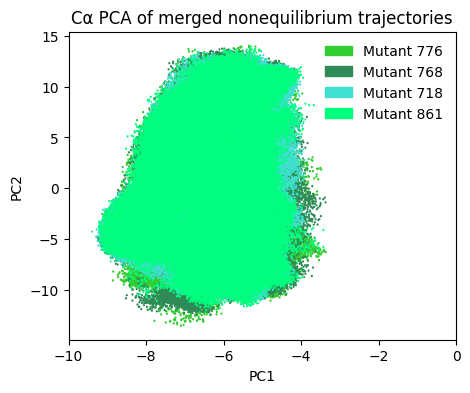

In [31]:

plt.figure(figsize=(5,4))
plt.hexbin(split_pcs["pc1_776"][1], split_pcs["pc2_776"][1], gridsize=300, mincnt=1, color ="limegreen", label = "Mutant 776")
plt.hexbin(split_pcs["pc1_768"][1], split_pcs["pc2_768"][1], gridsize=300, mincnt=1, color = "seagreen", label = "Mutant 768")
plt.hexbin(split_pcs["pc1_718"][1], split_pcs["pc2_718"][1], gridsize=300, mincnt=1, color = "turquoise", label = "Mutant 718")
plt.hexbin(split_pcs["pc1_861"][1], split_pcs["pc2_861"][1], gridsize=300, mincnt=1, color = "springgreen", label = "Mutant 861")
# plt.hexbin(split_pcs["pc1_eq"][1], split_pcs["pc2_eq"][1], gridsize=300, mincnt=1, color = "darkcyan", label = "Equilibrium")

plt.title("Cα PCA of merged nonequilibrium trajectories")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.xlim(-10, 0)
#plt.ylim(-12, 17)

plt.legend(loc = 1, frameon=False)

plt.savefig("mergedpca.png")

C:\Users\hamru\AppData\Local\Temp\ipykernel_36064\2546086517.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


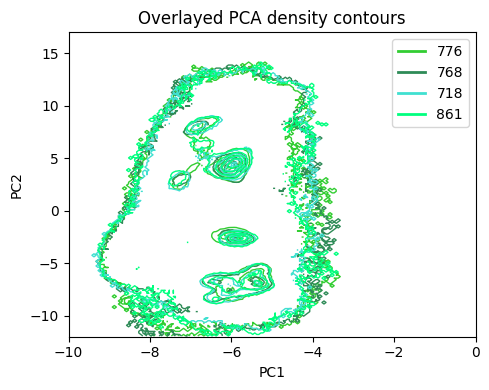

In [ ]:
#This cell plots the pca results as contours rather than hexbins
fig, ax = plt.subplots(figsize=(5, 4))

#common grid
x_min, x_max = -10, 0
y_min, y_max = -12, 17
bins = 200

def get_hist(x, y):
    H, xedges, yedges = np.histogram2d(
        x, y,
        bins=bins,
        range=[[x_min, x_max], [y_min, y_max]]
    )
    X = 0.5 * (xedges[:-1] + xedges[1:])
    Y = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(X, Y)
    return X, Y, H.T

#compute histograms
X, Y, H_776 = get_hist(split_pcs["pc1_776"][1], split_pcs["pc2_776"][1])
_, _, H_768 = get_hist(split_pcs["pc1_768"][1], split_pcs["pc2_768"][1])
_, _, H_718 = get_hist(split_pcs["pc1_718"][1], split_pcs["pc2_718"][1])
_, _, H_861 = get_hist(split_pcs["pc1_861"][1], split_pcs["pc2_861"][1])

#contour levels
levels = 5

ax.contour(X, Y, H_776, levels=levels, colors="limegreen", linewidths=1)
ax.contour(X, Y, H_768, levels=levels, colors="seagreen", linewidths=1)
ax.contour(X, Y, H_718, levels=levels, colors="turquoise", linewidths=1)
ax.contour(X, Y, H_861, levels=levels, colors="springgreen", linewidths=1)

ax.set_title("Overlayed PCA density contours")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.legend()

# manual legend
from matplotlib.lines import Line2D
legend_lines = [
    Line2D([0], [0], color="limegreen", lw=2, label="776"),
    Line2D([0], [0], color="seagreen", lw=2, label="768"),
    Line2D([0], [0], color="turquoise", lw=2, label="718"),
    Line2D([0], [0], color="springgreen", lw=2, label="861"),
]
ax.legend(handles=legend_lines)

plt.tight_layout()
plt.savefig("overlay_pca_contours.png")
plt.show()

In [ ]:
#If running many modes, this can be used to plot modes against eachother that look meaningfully different from the line graphs

x = 5
y = 7

plt.figure(figsize=(9,9))
plt.hexbin(split_pcs[f"pc{x}_776"][1], split_pcs[f"pc{y}_776"][1], gridsize=300, mincnt=1, color ="aquamarine", label = "Position 776")
plt.hexbin(split_pcs[f"pc{x}_768"][1], split_pcs[f"pc{y}_768"][1], gridsize=300, mincnt=1, color = "seagreen", label = "Position 768")
plt.hexbin(split_pcs[f"pc{x}_718"][1], split_pcs[f"pc{y}_718"][1], gridsize=300, mincnt=1, color = "turquoise", label = "Position 718")
plt.hexbin(split_pcs[f"pc{x}_861"][1], split_pcs[f"pc{y}_861"][1], gridsize=300, mincnt=1, color = "springgreen", label = "Position 861")
plt.hexbin(split_pcs[f"pc{x}_eq"][1], split_pcs[f"pc{y}_eq"][1], gridsize=300, mincnt=1, color = "darkcyan", label = "Equilibrium")

plt.title("PCA of merged equilibrium and nonequilibrium trajectories")
plt.xlabel(f"PC{x}")
plt.ylabel(f"PC{y}")

plt.legend(loc = 1)

KeyError: 'pc5_776'

<Figure size 900x900 with 0 Axes>

In [ ]:
# 768 varies, -10 in pc6 #Extract motion of pc6
#pc3, 776 varies from eq
#pc24 for 776 and 768 vary from eq
#pc 9 to 10 shows drift. perhaps motion is more common in mutants than in eq. Difference in pc9? 861 nice and different. as is 776


#24 25 also interesting
